In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import time

import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
url = "https://www.bikedekho.com/find-new-bikes"

url

'https://www.bikedekho.com/find-new-bikes'

In [3]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

In [4]:
page = requests.get(url, headers=headers, timeout=20)

print("Status Code:", page.status_code)
print("Page Length:", len(page.text))

Status Code: 200
Page Length: 766635


In [5]:
print(page.text[:1000])

<!DOCTYPE html><html lang="en"><head><meta charset="utf-8"><title>784 Bikes & Scooters Bikes & Scooters in India with prices</title><meta name="description" content="03 September 2026 - There are 784 Bikes & Scooters in India with prices The Lowest Price is of Elecson Eco with ex showroom price of Rs 13499, and the most expensive Bikes & Scooters is Ducati Panigale V4 at RS 8499000 ."> <link href="https://cdn.bikedekho.com" rel="preconnect"><link href="https://www.googletagmanager.com" rel="preconnect">   <link rel="preload" href="https://cdn.bikedekho.com/fonts/lato-regular.woff2" as="font" type="font/woff2" crossorigin="anonymous"><link rel="preload" href="https://cdn.bikedekho.com/fonts/lato-bold.woff2" as="font" type="font/woff2" crossorigin="anonymous">  <link rel="manifest" href="/manifest.json">  <meta name="ROBOTS" content="max-snippet:-1,max-image-preview:large"> <meta property="category" content="Auto"> <meta name="language" content="en">   <link rel="canonical" href="https:/

In [6]:
soup = BeautifulSoup(page.text, "html.parser")

print(soup.title)

<title>784 Bikes &amp; Scooters Bikes &amp; Scooters in India with prices</title>


In [7]:
print(soup.get_text(" ", strip=True)[:2000])

784 Bikes & Scooters Bikes & Scooters in India with prices Ad English Login / Register Bikes New Bikes Best Bikes Upcoming Bikes New Launches Popular Brands Finance Discount Offers Scooters New Scooters Best Scooters Upcoming Scooters New Launches Electric Two Wheelers Electric Bikes Electric Scooters Electric Cycles Charging Stations Compare News & Videos News & Top Stories Videos Web Stories Tools EMI Calculator Fuel Calculator Showrooms Bike Offers Used Bikes Search Used Bikes Sell Bike Select City Ad Bikes & Scooters in India There are 784 bikes currently on sale from various manufacturers starting from ₹16,184. The most popular products under this bracket are the Royal Enfield Classic 350 (₹2,14,270), Hero Splendor Plus (₹90,199) and Yamaha R15 V4 (₹2,00,468) (all prices on-road). To know more about the latest prices of in India in your city, get details on offers, variants, specifications, pictures, mileage, reviews, and more. Please select your desired bike from the list below. 

In [8]:
links = soup.find_all("a", href=True)

print("Total links:", len(links))

for link in links[:50]:
    print(link.get("href"))

Total links: 218
/
/new-bikes
/best-bikes
/upcoming-bikes
/latest-bikes
/new-bikes#all_brands
/finance-discount-offer
/scooters
/best-scooters
/upcoming-scooters
/latest-scooters
/electric-bikes
/electric-scooters
/find-electric-cycles
/electric-charging-station
/compare
/news
/videos
/web-stories
/bike-loan-emi-calculator
/fuel-calculator
/showrooms
/discount-offer.html
/usedBikes
/sell-used-bike
/royal-enfield/classic-350
/royal-enfield/classic-350/price-in-delhi
/royal-enfield/classic-350/specifications
/royal-enfield/classic350-redditch-series-with-dual-chennal.html
/royal-enfield/classic-350-heritage-premium.html
/royal-enfield/classic-350-heritage.html
/royal-enfield/classic350-signals-series-with-dual-chennal.html
/royal-enfield/classic350-dark-series-with-dual-chennal.html
/royal-enfield/classic350-chorme-series-with-dual-chennal.html
/hero/splendor-plus
/hero/splendor-plus/price-in-delhi
/hero/splendor-plus/specifications
/hero/splendor-plus-standard.html
/hero/splendor-plus-b

In [9]:
for link in links:
    href = link.get("href", "")
    
    if "classic-350" in href.lower() or "splendor" in href.lower() or "r15" in href.lower():
        print(href)

/royal-enfield/classic-350
/royal-enfield/classic-350/price-in-delhi
/royal-enfield/classic-350/specifications
/royal-enfield/classic-350-heritage-premium.html
/royal-enfield/classic-350-heritage.html
/hero/splendor-plus
/hero/splendor-plus/price-in-delhi
/hero/splendor-plus/specifications
/hero/splendor-plus-standard.html
/hero/splendor-plus-black-n-accent-obd-2b.html
/hero/splendor-plus-i3s-obd-2b.html
/hero/splendor-plus-million-edition.html
/yamaha/r15-v4
/yamaha/r15-v4/price-in-delhi
/yamaha/r15-v4/specifications
/yamaha/r15-v4-intensity-white-without-quickshifter.html
/yamaha/r15-v4-metallic-black.html
/yamaha/r15-v4-metallic-red.html
/yamaha/r15-v4-dark-knight.html
/yamaha/r15-v4-motogp-edition.html
/yamaha/r15-v4-intensity-white-with-quickshifter.html
/yamaha/r15-v4-matte-white-pearl.html
/yamaha/r15-v4-racing-blue.html
/yamaha/yzf-r15m.html
/yamaha/r15m-icon-performance.html
/yamaha/xsr155
/yamaha/xsr155/price-in-delhi
/yamaha/xsr155/specifications
/yamaha/xsr155-std.html
/yam

In [10]:
bike_urls = []

for link in links:
    href = link.get("href", "").strip()

    # Keep only main bike pages
    if (
        href.startswith("/")
        and href.count("/") == 2
        and not href.endswith(".html")
        and not any(x in href for x in [
            "/compare/",
            "/news/",
            "/finance/",
            "/road-test/",
            "/upcoming-bikes/"
        ])
    ):
        bike_urls.append("https://www.bikedekho.com" + href)

# Remove duplicates
bike_urls = list(dict.fromkeys(bike_urls))

print("Total bike URLs:", len(bike_urls))

print("\nFirst 20 bike URLs:")
for url in bike_urls[:20]:
    print(url)

Total bike URLs: 26

First 20 bike URLs:
https://www.bikedekho.com/royal-enfield/classic-350
https://www.bikedekho.com/hero/splendor-plus
https://www.bikedekho.com/yamaha/r15-v4
https://www.bikedekho.com/royal-enfield/hunter
https://www.bikedekho.com/honda/activa
https://www.bikedekho.com/royal-enfield/bullet-350
https://www.bikedekho.com/tvs/raider
https://www.bikedekho.com/tvs/apache-rtr-160
https://www.bikedekho.com/suzuki/access-125
https://www.bikedekho.com/yamaha/mt-15-v2
https://www.bikedekho.com/yamaha/xsr155
https://www.bikedekho.com/tvs/ronin
https://www.bikedekho.com/yamaha/ray-zr-125
https://www.bikedekho.com/honda/sp125
https://www.bikedekho.com/bajaj/chetak
https://www.bikedekho.com/tvs/jupiter
https://www.bikedekho.com/vida/vx2
https://www.bikedekho.com/hero/splendor-plus-xtec
https://www.bikedekho.com/hero/xpulse-210
https://www.bikedekho.com/yezdi-motorcycles/yezdi-roadster


In [11]:
print("Total:", len(bike_urls))

Total: 26


In [12]:
print(bike_urls[:10])

['https://www.bikedekho.com/royal-enfield/classic-350', 'https://www.bikedekho.com/hero/splendor-plus', 'https://www.bikedekho.com/yamaha/r15-v4', 'https://www.bikedekho.com/royal-enfield/hunter', 'https://www.bikedekho.com/honda/activa', 'https://www.bikedekho.com/royal-enfield/bullet-350', 'https://www.bikedekho.com/tvs/raider', 'https://www.bikedekho.com/tvs/apache-rtr-160', 'https://www.bikedekho.com/suzuki/access-125', 'https://www.bikedekho.com/yamaha/mt-15-v2']


In [13]:
test_url = bike_urls[0]

print(test_url)

https://www.bikedekho.com/royal-enfield/classic-350


In [14]:
test_page = requests.get(
    test_url,
    headers=headers,
    timeout=20
)

print("Status Code:", test_page.status_code)
print("Page Length:", len(test_page.text))

Status Code: 200
Page Length: 725097


In [15]:
test_soup = BeautifulSoup(test_page.text, "html.parser")

print(test_soup.title)

<title>Royal Enfield Classic 350 Price 2026 - Mileage, Colours, Images | BikeDekho</title>


In [16]:
text = test_soup.get_text(" ", strip=True)

print(text[:5000])

Royal Enfield Classic 350 Price 2026 - Mileage, Colours, Images | BikeDekho Ad English Login / Register Bikes New Bikes Best Bikes Upcoming Bikes New Launches Popular Brands Finance Discount Offers Scooters New Scooters Best Scooters Upcoming Scooters New Launches Electric Two Wheelers Electric Bikes Electric Scooters Electric Cycles Charging Stations Compare News & Videos News & Top Stories Videos Web Stories Tools EMI Calculator Fuel Calculator Showrooms Bike Offers Used Bikes Search Used Bikes Sell Bike Select City Ad Classic 350 Price Images Compare Specs Colours Classic 350 EMI User Reviews Mileage Videos More Showrooms Service Centers News FAQ's Spare Parts View September Offers 1 / 2 Start Engine Images Colours Videos View Royal Enfield Classic 350 4.4 User Reviews (752) Write a review Change Variant Redditch City Get ORP in my city Average On-Road Price ₹2,14,270 View Price Breakup EMI ₹5,879/month Get EMI offers View September Offers Royal Enfield Classic 350 Price & Variants 

In [17]:
spec_text = test_soup.get_text(" ", strip=True)

for keyword in ["Engine", "Power", "Torque", "Mileage"]:
    position = spec_text.find(keyword)
    print("\n", keyword, "position:", position)
    print(spec_text[position:position + 200])


 Engine position: 706
Engine Images Colours Videos View Royal Enfield Classic 350 4.4 User Reviews (752) Write a review Change Variant Redditch City Get ORP in my city Average On-Road Price ₹2,14,270 View Price Breakup EMI

 Power position: 1841
Power 20.21 PS Torque 27 Nm Mileage 41.55 kmpl Kerb Weight 195 kg Brakes Disc Navigation assist Yes As heritage as it gets: The vintage design is one of the biggest reasons why fans love the Classic 3

 Torque position: 1856
Torque 27 Nm Mileage 41.55 kmpl Kerb Weight 195 kg Brakes Disc Navigation assist Yes As heritage as it gets: The vintage design is one of the biggest reasons why fans love the Classic 350 Incredible r

 Mileage position: 39
Mileage, Colours, Images | BikeDekho Ad English Login / Register Bikes New Bikes Best Bikes Upcoming Bikes New Launches Popular Brands Finance Discount Offers Scooters New Scooters Best Scooters Upcom


In [18]:
engine = re.search(r'Engine\s+(\d+(?:\.\d+)?)\s*cc', spec_text)
power = re.search(r'Power\s+(\d+(?:\.\d+)?)\s*PS', spec_text)
torque = re.search(r'Torque\s+(\d+(?:\.\d+)?)\s*Nm', spec_text)
mileage = re.search(r'Mileage\s+(\d+(?:\.\d+)?)\s*kmpl', spec_text)

print("Engine:", engine.group(1) if engine else None)
print("Power:", power.group(1) if power else None)
print("Torque:", torque.group(1) if torque else None)
print("Mileage:", mileage.group(1) if mileage else None)

Engine: 349
Power: 20.21
Torque: 27
Mileage: 41.55


In [19]:
title = test_soup.title.get_text(strip=True)

print(title)

Royal Enfield Classic 350 Price 2026 - Mileage, Colours, Images | BikeDekho


In [20]:
bike_name = title.split(" Price")[0]

print("Bike Name:", bike_name)

Bike Name: Royal Enfield Classic 350


In [21]:
price_match = re.search(
    r'Average On-Road Price\s*₹\s*([\d,]+)',
    spec_text
)

price = price_match.group(1).replace(",", "") if price_match else None

print("Price:", price)

Price: 214270


In [22]:
bike_data = {
    "Name": bike_name,
    "Price": price,
    "Engine": engine.group(1) if engine else None,
    "Power": power.group(1) if power else None,
    "Torque": torque.group(1) if torque else None,
    "Mileage": mileage.group(1) if mileage else None
}

bike_data

{'Name': 'Royal Enfield Classic 350',
 'Price': '214270',
 'Engine': '349',
 'Power': '20.21',
 'Torque': '27',
 'Mileage': '41.55'}

In [23]:
def scrape_bike(url):
    try:
        page = requests.get(url, headers=headers, timeout=20)
        soup = BeautifulSoup(page.text, "html.parser")
        text = soup.get_text(" ", strip=True)

        # Bike name
        title = soup.title.get_text(strip=True) if soup.title else ""
        bike_name = title.split(" Price")[0]

        # Price
        price_match = re.search(
            r'Average On-Road Price\s*₹\s*([\d,]+)',
            text
        )

        # Specifications
        engine = re.search(
            r'Engine\s+(\d+(?:\.\d+)?)\s*cc',
            text
        )

        power = re.search(
            r'Power\s+(\d+(?:\.\d+)?)\s*PS',
            text
        )

        torque = re.search(
            r'Torque\s+(\d+(?:\.\d+)?)\s*Nm',
            text
        )

        mileage = re.search(
            r'Mileage\s+(\d+(?:\.\d+)?)\s*kmpl',
            text
        )

        return {
            "Name": bike_name,
            "Price": price_match.group(1).replace(",", "") if price_match else None,
            "Engine": engine.group(1) if engine else None,
            "Power": power.group(1) if power else None,
            "Torque": torque.group(1) if torque else None,
            "Mileage": mileage.group(1) if mileage else None,
            "URL": url
        }

    except Exception as e:
        print("Error:", url, e)
        return None

In [24]:
result = scrape_bike(bike_urls[0])

result

{'Name': 'Royal Enfield Classic 350',
 'Price': '214270',
 'Engine': '349',
 'Power': '20.21',
 'Torque': '27',
 'Mileage': '41.55',
 'URL': 'https://www.bikedekho.com/royal-enfield/classic-350'}

In [25]:
all_bikes = []

for i, url in enumerate(bike_urls):
    print(f"Scraping {i+1}/{len(bike_urls)}")

    data = scrape_bike(url)

    if data:
        all_bikes.append(data)

    time.sleep(1)

Scraping 1/26
Scraping 2/26
Scraping 3/26
Scraping 4/26
Scraping 5/26
Scraping 6/26
Scraping 7/26
Scraping 8/26
Scraping 9/26
Scraping 10/26
Scraping 11/26
Scraping 12/26
Scraping 13/26
Scraping 14/26
Scraping 15/26
Scraping 16/26
Scraping 17/26
Scraping 18/26
Scraping 19/26
Scraping 20/26
Scraping 21/26
Scraping 22/26
Scraping 23/26
Scraping 24/26
Scraping 25/26
Scraping 26/26


In [26]:
df = pd.DataFrame(all_bikes)

print("Shape:", df.shape)

df.head()

Shape: (26, 7)


,Name,Price,Engine,Power,Torque,Mileage,URL
0,Royal Enfield Classic 350,214270,349,20.21,27,41.55,https://www.bikedekho.com/royal-enfield/classi...
1,"Hero Splendor Plus - India's No.1 Selling Bike,",None,97.2,8.02,8.05,70,https://www.bikedekho.com/hero/splendor-plus
2,New Yamaha R15 V4,None,155,18.4,14.2,45,https://www.bikedekho.com/yamaha/r15-v4
3,Royal Enfield Hunter 350,159656,349,20.21,27,36.2,https://www.bikedekho.com/royal-enfield/hunter
4,"Honda Activa - India's No.1 Selling Scooter,",None,109.51,7.99,9.05,59.5,https://www.bikedekho.com/honda/activa


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     26 non-null     object
 1   Price    6 non-null      object
 2   Engine   24 non-null     object
 3   Power    24 non-null     object
 4   Torque   25 non-null     object
 5   Mileage  23 non-null     object
 6   URL      26 non-null     object
dtypes: object(7)
memory usage: 1.6+ KB


In [28]:
df.isnull().sum()

Name        0
Price      20
Engine      2
Power       2
Torque      1
Mileage     3
URL         0
dtype: int64

In [29]:
df.to_csv("bikedekho_raw.csv", index=False)

print("Raw dataset saved successfully.")

Raw dataset saved successfully.


In [30]:
numeric_columns = [
    "Price",
    "Engine",
    "Power",
    "Torque",
    "Mileage"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Name     26 non-null     object 
 1   Price    6 non-null      float64
 2   Engine   24 non-null     float64
 3   Power    24 non-null     float64
 4   Torque   25 non-null     float64
 5   Mileage  23 non-null     float64
 6   URL      26 non-null     object 
dtypes: float64(5), object(2)
memory usage: 1.6+ KB


In [32]:
df.isnull().sum()

Name        0
Price      20
Engine      2
Power       2
Torque      1
Mileage     3
URL         0
dtype: int64

In [33]:
df[df["Price"].isnull()][["Name", "URL"]]

,Name,URL
1,"Hero Splendor Plus - India's No.1 Selling Bike,",https://www.bikedekho.com/hero/splendor-plus
2,New Yamaha R15 V4,https://www.bikedekho.com/yamaha/r15-v4
4,"Honda Activa - India's No.1 Selling Scooter,",https://www.bikedekho.com/honda/activa
6,TVS Raider,https://www.bikedekho.com/tvs/raider
7,TVS Apache RTR 160,https://www.bikedekho.com/tvs/apache-rtr-160
9,Yamaha MT 15 Version 2.0,https://www.bikedekho.com/yamaha/mt-15-v2
10,Yamaha XSR 155,https://www.bikedekho.com/yamaha/xsr155
11,TVS Ronin 225 BS6,https://www.bikedekho.com/tvs/ronin
12,New Yamaha RayZR 125 Fi Hybrid,https://www.bikedekho.com/yamaha/ray-zr-125
13,New Honda SP 125:,https://www.bikedekho.com/honda/sp125


In [34]:
missing_url = df[df["Price"].isnull()]["URL"].iloc[0]

print(missing_url)

https://www.bikedekho.com/hero/splendor-plus


In [35]:
missing_page = requests.get(
    missing_url,
    headers=headers,
    timeout=20
)

missing_soup = BeautifulSoup(
    missing_page.text,
    "html.parser"
)

missing_text = missing_soup.get_text(" ", strip=True)

print(missing_text[:3000])

Hero Splendor Plus - India's No.1 Selling Bike, Price, Offer Ad English Login / Register Bikes New Bikes Best Bikes Upcoming Bikes New Launches Popular Brands Finance Discount Offers Scooters New Scooters Best Scooters Upcoming Scooters New Launches Electric Two Wheelers Electric Bikes Electric Scooters Electric Cycles Charging Stations Compare News & Videos News & Top Stories Videos Web Stories Tools EMI Calculator Fuel Calculator Showrooms Bike Offers Used Bikes Search Used Bikes Sell Bike Select City Ad Splendor Plus Price Images Compare Specs Colours Splendor Plus EMI User Reviews Mileage Videos More Showrooms Service Centers News FAQ's Service Cost Spare Parts Second Hand Splendor Plus View September Offers 1 / 2 49 Images 9 Colours Videos 360º View Hero Splendor Plus 4.4 1.49k Reviews Write Review Rs. 77,777 onwards Get On Road Price Average Ex-Showroom Price Select City EMI starts @ ₹2,609 View Finance Offers View September Offers Don't miss out on the best offers this September

In [36]:
positions = [
    m.start()
    for m in re.finditer("Price", missing_text, re.IGNORECASE)
]

print("Number of Price occurrences:", len(positions))

for pos in positions[:10]:
    print("\n---")
    print(missing_text[pos:pos+250])

Number of Price occurrences: 39

---
Price, Offer Ad English Login / Register Bikes New Bikes Best Bikes Upcoming Bikes New Launches Popular Brands Finance Discount Offers Scooters New Scooters Best Scooters Upcoming Scooters New Launches Electric Two Wheelers Electric Bikes Electric Sc

---
Price Images Compare Specs Colours Splendor Plus EMI User Reviews Mileage Videos More Showrooms Service Centers News FAQ's Service Cost Spare Parts Second Hand Splendor Plus View September Offers 1 / 2 49 Images 9 Colours Videos 360º View Hero Splend

---
Price Average Ex-Showroom Price Select City EMI starts @ ₹2,609 View Finance Offers View September Offers Don't miss out on the best offers this September Hero Splendor Plus Variants and Price The price of Hero Splendor Plus in India starts at Rs. 77

---
Price Select City EMI starts @ ₹2,609 View Finance Offers View September Offers Don't miss out on the best offers this September Hero Splendor Plus Variants and Price The price of Hero Splendor P

In [37]:
price_match = re.search(
    r'(?:starts at|Rs\.)\s*\.?\s*([\d,]+)',
    missing_text,
    re.IGNORECASE
)

if price_match:
    print("Price:", price_match.group(1))
else:
    print("Price not found")

Price: 77,777


In [38]:
def scrape_bike(url):
    try:
        page = requests.get(
            url,
            headers=headers,
            timeout=20
        )

        soup = BeautifulSoup(
            page.text,
            "html.parser"
        )

        text = soup.get_text(" ", strip=True)

        # -------------------------
        # Bike Name
        # -------------------------
        title = soup.title.get_text(strip=True) if soup.title else ""

        bike_name = title.split(" Price")[0]

        # -------------------------
        # Price
        # -------------------------
        price_match = re.search(
            r'(?:starts at|Rs\.)\s*\.?\s*([\d,]+)',
            text,
            re.IGNORECASE
        )

        # -------------------------
        # Engine
        # -------------------------
        engine = re.search(
            r'Engine\s+(\d+(?:\.\d+)?)\s*cc',
            text,
            re.IGNORECASE
        )

        # -------------------------
        # Power
        # -------------------------
        power = re.search(
            r'Power\s+(\d+(?:\.\d+)?)\s*PS',
            text,
            re.IGNORECASE
        )

        # -------------------------
        # Torque
        # -------------------------
        torque = re.search(
            r'Torque\s+(\d+(?:\.\d+)?)\s*Nm',
            text,
            re.IGNORECASE
        )

        # -------------------------
        # Mileage
        # -------------------------
        mileage = re.search(
            r'Mileage\s+(\d+(?:\.\d+)?)\s*kmpl',
            text,
            re.IGNORECASE
        )

        return {
            "Name": bike_name,
            "Price": (
                price_match.group(1).replace(",", "")
                if price_match else None
            ),
            "Engine": (
                engine.group(1)
                if engine else None
            ),
            "Power": (
                power.group(1)
                if power else None
            ),
            "Torque": (
                torque.group(1)
                if torque else None
            ),
            "Mileage": (
                mileage.group(1)
                if mileage else None
            ),
            "URL": url
        }

    except Exception as e:
        print("Error:", url, e)
        return None

In [39]:
result = scrape_bike(
    "https://www.bikedekho.com/hero/splendor-plus"
)

result

{'Name': "Hero Splendor Plus - India's No.1 Selling Bike,",
 'Price': '77777',
 'Engine': '97.2',
 'Power': '8.02',
 'Torque': '8.05',
 'Mileage': '70',
 'URL': 'https://www.bikedekho.com/hero/splendor-plus'}

In [40]:
all_bikes = []

for i, url in enumerate(bike_urls):
    
    print(f"Scraping {i+1}/{len(bike_urls)}")
    
    data = scrape_bike(url)

    if data:
        all_bikes.append(data)

    time.sleep(1)

Scraping 1/26
Scraping 2/26
Scraping 3/26
Scraping 4/26
Scraping 5/26
Scraping 6/26
Scraping 7/26
Scraping 8/26
Scraping 9/26
Scraping 10/26
Scraping 11/26
Scraping 12/26
Scraping 13/26
Scraping 14/26
Scraping 15/26
Scraping 16/26
Scraping 17/26
Scraping 18/26
Scraping 19/26
Scraping 20/26
Scraping 21/26
Scraping 22/26
Scraping 23/26
Scraping 24/26
Scraping 25/26
Scraping 26/26


In [41]:
df = pd.DataFrame(all_bikes)

print("Shape:", df.shape)

Shape: (26, 7)


In [42]:
df.isnull().sum()

Name       0
Price      0
Engine     2
Power      2
Torque     1
Mileage    4
URL        0
dtype: int64

In [43]:
df[df[["Engine", "Power", "Torque", "Mileage"]].isnull().any(axis=1)]

,Name,Price,Engine,Power,Torque,Mileage,URL
12,New Yamaha RayZR 125 Fi Hybrid,79880,125,8.2,10.3,None,https://www.bikedekho.com/yamaha/ray-zr-125
14,New Bajaj Chetak,119270,None,None,None,None,https://www.bikedekho.com/bajaj/chetak
16,Vida VX2,84999,None,None,25,None,https://www.bikedekho.com/vida/vx2
20,New Triumph Speed 400,265498,349,37,32,None,https://www.bikedekho.com/triumph/speed-400


In [44]:
for col in ["Engine", "Power", "Torque", "Mileage"]:
    print("\n", col)
    print(df[df[col].isnull()][["Name", "URL"]])


 Engine
                Name                                     URL
14  New Bajaj Chetak  https://www.bikedekho.com/bajaj/chetak
16          Vida VX2      https://www.bikedekho.com/vida/vx2

 Power
                Name                                     URL
14  New Bajaj Chetak  https://www.bikedekho.com/bajaj/chetak
16          Vida VX2      https://www.bikedekho.com/vida/vx2

 Torque
                Name                                     URL
14  New Bajaj Chetak  https://www.bikedekho.com/bajaj/chetak

 Mileage
                              Name  \
12  New Yamaha RayZR 125 Fi Hybrid   
14                New Bajaj Chetak   
16                        Vida VX2   
20           New Triumph Speed 400   

                                            URL  
12  https://www.bikedekho.com/yamaha/ray-zr-125  
14       https://www.bikedekho.com/bajaj/chetak  
16           https://www.bikedekho.com/vida/vx2  
20  https://www.bikedekho.com/triumph/speed-400  


In [45]:
missing_rows = df[
    df[["Engine", "Power", "Torque", "Mileage"]].isnull().any(axis=1)
]

missing_rows[["Name", "URL"]]

,Name,URL
12,New Yamaha RayZR 125 Fi Hybrid,https://www.bikedekho.com/yamaha/ray-zr-125
14,New Bajaj Chetak,https://www.bikedekho.com/bajaj/chetak
16,Vida VX2,https://www.bikedekho.com/vida/vx2
20,New Triumph Speed 400,https://www.bikedekho.com/triumph/speed-400


In [46]:
for url in missing_rows["URL"]:
    print("\n" + "="*80)
    print(url)

    page = requests.get(
        url,
        headers=headers,
        timeout=20
    )

    soup = BeautifulSoup(page.text, "html.parser")
    text = soup.get_text(" ", strip=True)

    for keyword in ["Engine", "Power", "Torque", "Mileage"]:
        pos = text.find(keyword)

        print("\n", keyword)
        print(text[pos:pos+150])


https://www.bikedekho.com/yamaha/ray-zr-125

 Engine
Engine 125 cc Power 8.2 PS Torque 10.3 Nm Kerb Weight 99 kg Brakes Drum Tyre Type Tubeless All Specifications Key Specs All Specifications View More S

 Power
Power 8.2 PS Torque 10.3 Nm Kerb Weight 99 kg Brakes Drum Tyre Type Tubeless All Specifications Key Specs All Specifications View More Specifications 

 Torque
Torque 10.3 Nm Kerb Weight 99 kg Brakes Drum Tyre Type Tubeless All Specifications Key Specs All Specifications View More Specifications Yamaha RayZR 

 Mileage
Mileage, Colours, Images | BikeDekho Ad English Login / Register Bikes New Bikes Best Bikes Upcoming Bikes New Launches Popular Brands Finance Discoun

https://www.bikedekho.com/bajaj/chetak

 Engine


 Power
Power - Power 1.8 kW Power - Power 6 kW Power 6.4 kW Power 6 kW Power 4.3 kW Power 5.5 kW Power 4 kW Charging Time - Charging Time - Charging Time 3.4

 Torque
Torque Motor - Torque Motor 30 Nm Torque Motor - Torque Motor 25 Nm Torque Motor 26 Nm Torque Mot

In [47]:
for url in missing_rows["URL"]:
    print("\n" + "=" * 80)
    print(url)

    page = requests.get(
        url,
        headers=headers,
        timeout=20
    )

    soup = BeautifulSoup(page.text, "html.parser")
    text = soup.get_text(" ", strip=True)

    # Print areas containing important EV specifications
    for keyword in ["Motor", "Power", "Torque", "Range"]:
        positions = [
            m.start()
            for m in re.finditer(keyword, text, re.IGNORECASE)
        ]

        print("\n", keyword)

        for pos in positions[:3]:
            print(text[pos:pos+250])


https://www.bikedekho.com/yamaha/ray-zr-125

 Motor
Motor Generator (SMG)-based hybrid system. It provides torque assist during acceleration, making launches smoother and overtakes more efficient. Other features include a fully digital instrument cluster, with the top Street Rally variant getting a co

 Power
Power 8.2 PS Torque 10.3 Nm Kerb Weight 99 kg Brakes Drum Tyre Type Tubeless All Specifications Key Specs All Specifications View More Specifications Yamaha RayZR 125 Fi Hybrid comparison with similar Scooters Yamaha RayZR 125 Fi Hybrid Rs. 79,880 * 
Power 8.2 PS @ 6500 rpm 8.02 PS @ 6500 rpm 9.5 PS @ 7000 rpm Not Applicable 7.99 PS @ 8000 rpm 8.42 PS @ 6500 rpm 6 kW 8.42 PS @ 6500 rpm 6 kW Top Speed 91 kmph 82 kmph 94 kmph 70 km/Hr 85 kmph 90 kmph 70 km/Hr - 80 km/Hr Torque 10.3 Nm @ 5000 rpm 9.
power assist is in operation. Additionally, making quick overtakes feels effortless on the RayZR. Highway Performance While the RayZR can reach speeds of 90kmph, it isn’t really designed

In [48]:
df["Power_kW"] = np.nan
df["Range_km"] = np.nan

In [49]:
df.loc[
    df["Name"].str.contains("Chetak", case=False, na=False),
    "Power_kW"
] = 6

df.loc[
    df["Name"].str.contains("Chetak", case=False, na=False),
    "Range_km"
] = 131


df.loc[
    df["Name"].str.contains("Vida VX2", case=False, na=False),
    "Power_kW"
] = 6

df.loc[
    df["Name"].str.contains("Vida VX2", case=False, na=False),
    "Range_km"
] = 93

In [50]:
df[df["Power_kW"].notnull()][
    ["Name", "Price", "Power_kW", "Torque", "Range_km"]
]

,Name,Price,Power_kW,Torque,Range_km
14,New Bajaj Chetak,119270,6.0,None,131.0
16,Vida VX2,84999,6.0,25,93.0


In [51]:
ev_mask = df["Power_kW"].notnull()

df.loc[ev_mask, "Engine"] = np.nan
df.loc[ev_mask, "Power"] = np.nan
df.loc[ev_mask, "Mileage"] = np.nan

In [52]:
df[df["Power_kW"].notnull()]

,Name,Price,Engine,Power,Torque,Mileage,URL,Power_kW,Range_km
14,New Bajaj Chetak,119270,NaN,NaN,None,NaN,https://www.bikedekho.com/bajaj/chetak,6.0,131.0
16,Vida VX2,84999,NaN,NaN,25,NaN,https://www.bikedekho.com/vida/vx2,6.0,93.0


In [53]:
df.isnull().sum()

Name         0
Price        0
Engine       2
Power        2
Torque       1
Mileage      4
URL          0
Power_kW    24
Range_km    24
dtype: int64

In [54]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [55]:
print("Duplicate bike names:", df["Name"].duplicated().sum())

Duplicate bike names: 0


In [56]:
df.describe()

,Power_kW,Range_km
count,2.0,2.000000
mean,6.0,112.000000
std,0.0,26.870058
min,6.0,93.000000
25%,6.0,102.500000
50%,6.0,112.000000
75%,6.0,121.500000
max,6.0,131.000000


In [57]:
for col in ["Price", "Engine", "Power", "Torque", "Mileage", "Power_kW", "Range_km"]:
    print("\n", col)
    print(df[col].sort_values().to_list())


 Price
['100400', '113890', '119270', '130290', '149990', '159656', '165610', '166745', '174850', '190384', '199969', '204950', '214270', '226767', '265498', '356381', '426223', '74125', '76083', '77777', '79880', '81283', '83910', '84999', '89748', '91500']

 Engine
['109.51', '113.3', '123.94', '124', '124.7', '124.8', '125', '155', '155', '155', '159.7', '210', '225.9', '249.07', '296', '334', '334', '349', '349', '349', '349', '457', '97.2', '97.2', nan, nan]

 Power
['10.87', '11.38', '11.55', '16.04', '18.4', '18.4', '18.4', '20.21', '20.21', '20.21', '20.4', '24.6', '29.17', '29.92', '31', '37', '39', '47.58', '7.99', '8.02', '8.02', '8.02', '8.2', '8.42', nan, nan]

 Torque
['10.2', '10.3', '10.5', '10.9', '11.2', '13.85', '14.1', '14.2', '14.2', '19.93', '20.7', '25', '25', '26.1', '27', '27', '27', '29.63', '30', '32', '43.5', '8.05', '8.05', '9.05', '9.2', None]

 Mileage
['29.06', '30', '30', '30.08', '30.56', '36.2', '37', '40', '41.55', '42.95', '45', '45', '45.5', '47',

In [58]:
missing_specs = df[
    df[["Engine", "Power", "Torque", "Mileage"]].isnull().any(axis=1)
]

missing_specs[
    ["Name", "Engine", "Power", "Torque", "Mileage"]
]

,Name,Engine,Power,Torque,Mileage
12,New Yamaha RayZR 125 Fi Hybrid,125,8.2,10.3,None
14,New Bajaj Chetak,NaN,NaN,None,NaN
16,Vida VX2,NaN,NaN,25,NaN
20,New Triumph Speed 400,349,37,32,None


In [59]:
missing_specs[
    ["Name", "Price", "Engine", "Power", "Torque", "Mileage"]
]

,Name,Price,Engine,Power,Torque,Mileage
12,New Yamaha RayZR 125 Fi Hybrid,79880,125,8.2,10.3,None
14,New Bajaj Chetak,119270,NaN,NaN,None,NaN
16,Vida VX2,84999,NaN,NaN,25,NaN
20,New Triumph Speed 400,265498,349,37,32,None


# 7. Read CSV File

The cleaned BikeDekho DataFrame is exported to CSV and then imported again for the remaining analysis.

In [60]:
df["Power_kW"] = pd.to_numeric(df.get("Power_kW", np.nan), errors="coerce")
df["Range_km"] = pd.to_numeric(df.get("Range_km", np.nan), errors="coerce")

df.loc[df["Name"].str.contains("Chetak", case=False, na=False), "Power_kW"] = 6
df.loc[df["Name"].str.contains("Chetak", case=False, na=False), "Range_km"] = 131
df.loc[df["Name"].str.contains("Vida VX2", case=False, na=False), "Power_kW"] = 6
df.loc[df["Name"].str.contains("Vida VX2", case=False, na=False), "Range_km"] = 93

df.loc[df["Name"].str.contains("Chetak", case=False, na=False), "Torque"] = 30

df["Vehicle_Type"] = np.where(df["Power_kW"].notna(), "Electric", "Petrol")

ev_mask = df["Vehicle_Type"].eq("Electric")
df.loc[ev_mask, ["Engine", "Power", "Mileage"]] = np.nan

df.to_csv("bikedekho_cleaned.csv", index=False)
df = pd.read_csv("bikedekho_cleaned.csv")

print("CSV file exported and imported successfully.")
df.head()

CSV file exported and imported successfully.


,Name,Price,Engine,Power,Torque,Mileage,URL,Power_kW,Range_km,Vehicle_Type
0,Royal Enfield Classic 350,214270,349.00,20.21,27.00,41.55,https://www.bikedekho.com/royal-enfield/classi...,NaN,NaN,Petrol
1,"Hero Splendor Plus - India's No.1 Selling Bike,",77777,97.20,8.02,8.05,70.00,https://www.bikedekho.com/hero/splendor-plus,NaN,NaN,Petrol
2,New Yamaha R15 V4,174850,155.00,18.40,14.20,45.00,https://www.bikedekho.com/yamaha/r15-v4,NaN,NaN,Petrol
3,Royal Enfield Hunter 350,159656,349.00,20.21,27.00,36.20,https://www.bikedekho.com/royal-enfield/hunter,NaN,NaN,Petrol
4,"Honda Activa - India's No.1 Selling Scooter,",76083,109.51,7.99,9.05,59.50,https://www.bikedekho.com/honda/activa,NaN,NaN,Petrol


In [61]:
rows, columns = df.shape
print("Number of observations (rows):", rows)
print("Number of features (columns):", columns)

Number of observations (rows): 26
Number of features (columns): 10


In [62]:
print(df.dtypes)

Name             object
Price             int64
Engine          float64
Power           float64
Torque          float64
Mileage         float64
URL              object
Power_kW        float64
Range_km        float64
Vehicle_Type     object
dtype: object


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          26 non-null     object 
 1   Price         26 non-null     int64  
 2   Engine        24 non-null     float64
 3   Power         24 non-null     float64
 4   Torque        26 non-null     float64
 5   Mileage       22 non-null     float64
 6   URL           26 non-null     object 
 7   Power_kW      2 non-null      float64
 8   Range_km      2 non-null      float64
 9   Vehicle_Type  26 non-null     object 
dtypes: float64(6), int64(1), object(3)
memory usage: 2.2+ KB


In [64]:
missing_values = df.isnull().sum()
print(missing_values)

print("\nMissing percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

Name             0
Price            0
Engine           2
Power            2
Torque           0
Mileage          4
URL              0
Power_kW        24
Range_km        24
Vehicle_Type     0
dtype: int64

Missing percentage:
Name             0.00
Price            0.00
Engine           7.69
Power            7.69
Torque           0.00
Mileage         15.38
URL              0.00
Power_kW        92.31
Range_km        92.31
Vehicle_Type     0.00
dtype: float64


In [65]:
print("========== DATASET SUMMARY ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

========== DATASET SUMMARY ==========
Rows: 26
Columns: 10

Columns:
['Name', 'Price', 'Engine', 'Power', 'Torque', 'Mileage', 'URL', 'Power_kW', 'Range_km', 'Vehicle_Type']

Data Types:
Name             object
Price             int64
Engine          float64
Power           float64
Torque          float64
Mileage         float64
URL              object
Power_kW        float64
Range_km        float64
Vehicle_Type     object
dtype: object

Missing Values:
Name             0
Price            0
Engine           2
Power            2
Torque           0
Mileage          4
URL              0
Power_kW        24
Range_km        24
Vehicle_Type     0
dtype: int64


### Interpretation – Reading the CSV File

The BikeDekho dataset was exported into CSV format and imported back into the notebook. The dataset contains **26 observations** and **10 features** after adding the vehicle type variable. The features include bike name, price, petrol-bike specifications, URL, electric-bike power/range and vehicle type.

The data types and missing values were checked before continuing to the cleaning stage. Missing Engine, Power and Mileage values for electric bikes are expected because those specifications are not applicable to electric vehicles.

# 8. Clean the Data

In [66]:
rename_map = {
    "Name": "Name",
    "Price": "Price",
    "Engine": "Engine",
    "Power": "Power",
    "Torque": "Torque",
    "Mileage": "Mileage",
    "URL": "URL",
    "Power_kW": "Power_kW",
    "Range_km": "Range_km",
    "Vehicle_Type": "Vehicle_Type"
}
df = df.rename(columns=rename_map)
df.columns = df.columns.str.strip()
print("Standardized columns:")
print(df.columns.tolist())

Standardized columns:
['Name', 'Price', 'Engine', 'Power', 'Torque', 'Mileage', 'URL', 'Power_kW', 'Range_km', 'Vehicle_Type']


In [67]:
df["Name"] = (
    df["Name"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["URL"] = df["URL"].astype(str).str.strip()

print(df[["Name", "URL"]].head())

                                              Name  \
0                        Royal Enfield Classic 350   
1  Hero Splendor Plus - India's No.1 Selling Bike,   
2                                New Yamaha R15 V4   
3                         Royal Enfield Hunter 350   
4     Honda Activa - India's No.1 Selling Scooter,   

                                                 URL  
0  https://www.bikedekho.com/royal-enfield/classi...  
1       https://www.bikedekho.com/hero/splendor-plus  
2            https://www.bikedekho.com/yamaha/r15-v4  
3     https://www.bikedekho.com/royal-enfield/hunter  
4             https://www.bikedekho.com/honda/activa  


In [68]:
df.columns = df.columns.str.strip()
df["Name"] = df["Name"].astype(str).str.strip()

print("Duplicate rows before removal:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after removal:", df.duplicated().sum())

print("Duplicate bike names:", df["Name"].duplicated().sum())

Duplicate rows before removal: 0
Duplicate rows after removal: 0
Duplicate bike names: 0


In [69]:
numeric_columns = [
    "Price", "Engine", "Power", "Torque", "Mileage", "Power_kW", "Range_km"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)

Name             object
Price             int64
Engine          float64
Power           float64
Torque          float64
Mileage         float64
URL              object
Power_kW        float64
Range_km        float64
Vehicle_Type     object
dtype: object


In [70]:
for col in numeric_columns:
    print(f"{col}: {(df[col] < 0).sum()} negative values")

for col in numeric_columns:
    df.loc[df[col] < 0, col] = np.nan

Price: 0 negative values
Engine: 0 negative values
Power: 0 negative values
Torque: 0 negative values
Mileage: 0 negative values
Power_kW: 0 negative values
Range_km: 0 negative values


In [71]:
print("Missing values:")
print(df.isnull().sum())

print("\nRows containing missing values:")
display(df[df.isnull().any(axis=1)])

Missing values:
Name             0
Price            0
Engine           2
Power            2
Torque           0
Mileage          4
URL              0
Power_kW        24
Range_km        24
Vehicle_Type     0
dtype: int64

Rows containing missing values:


,Name,Price,Engine,Power,Torque,Mileage,URL,Power_kW,Range_km,Vehicle_Type
0,Royal Enfield Classic 350,214270.0,349.00,20.21,27.00,41.55,https://www.bikedekho.com/royal-enfield/classi...,NaN,NaN,Petrol
1,"Hero Splendor Plus - India's No.1 Selling Bike,",77777.0,97.20,8.02,8.05,70.00,https://www.bikedekho.com/hero/splendor-plus,NaN,NaN,Petrol
2,New Yamaha R15 V4,174850.0,155.00,18.40,14.20,45.00,https://www.bikedekho.com/yamaha/r15-v4,NaN,NaN,Petrol
3,Royal Enfield Hunter 350,159656.0,349.00,20.21,27.00,36.20,https://www.bikedekho.com/royal-enfield/hunter,NaN,NaN,Petrol
4,"Honda Activa - India's No.1 Selling Scooter,",76083.0,109.51,7.99,9.05,59.50,https://www.bikedekho.com/honda/activa,NaN,NaN,Petrol
5,"Royal Enfield Bullet 350 - Icon Since 1932,",190384.0,349.00,20.21,27.00,37.00,https://www.bikedekho.com/royal-enfield/bullet...,NaN,NaN,Petrol
6,TVS Raider,83910.0,124.80,11.38,11.20,71.94,https://www.bikedekho.com/tvs/raider,NaN,NaN,Petrol
7,TVS Apache RTR 160,113890.0,159.70,16.04,13.85,47.00,https://www.bikedekho.com/tvs/apache-rtr-160,NaN,NaN,Petrol
8,"Suzuki Access 125 - Scooter Of The Year,",100400.0,124.00,8.42,10.20,45.00,https://www.bikedekho.com/suzuki/access-125,NaN,NaN,Petrol
9,Yamaha MT 15 Version 2.0,165610.0,155.00,18.40,14.10,56.87,https://www.bikedekho.com/yamaha/mt-15-v2,NaN,NaN,Petrol


In [72]:
def iqr_outlier_summary(data, col):
    s = data[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((s < lower) | (s > upper)).sum()
    return q1, q3, lower, upper, int(count)

for col in ["Price", "Engine", "Power", "Torque", "Mileage"]:
    q1, q3, lower, upper, count = iqr_outlier_summary(df, col)
    print(f"{col}: Q1={q1:.2f}, Q3={q3:.2f}, Lower={lower:.2f}, Upper={upper:.2f}, Outliers={count}")

Price: Q1=86186.25, Q3=197572.75, Lower=-80893.50, Upper=364652.50, Outliers=1
Engine: Q1=124.53, Q3=334.00, Lower=-189.69, Upper=648.21, Outliers=0
Power: Q1=10.26, Q3=25.74, Lower=-12.97, Upper=48.97, Outliers=0
Torque: Q1=10.60, Q3=27.00, Lower=-14.00, Upper=51.60, Outliers=0
Mileage: Q1=36.40, Q3=60.78, Lower=-0.16, Upper=97.34, Outliers=0


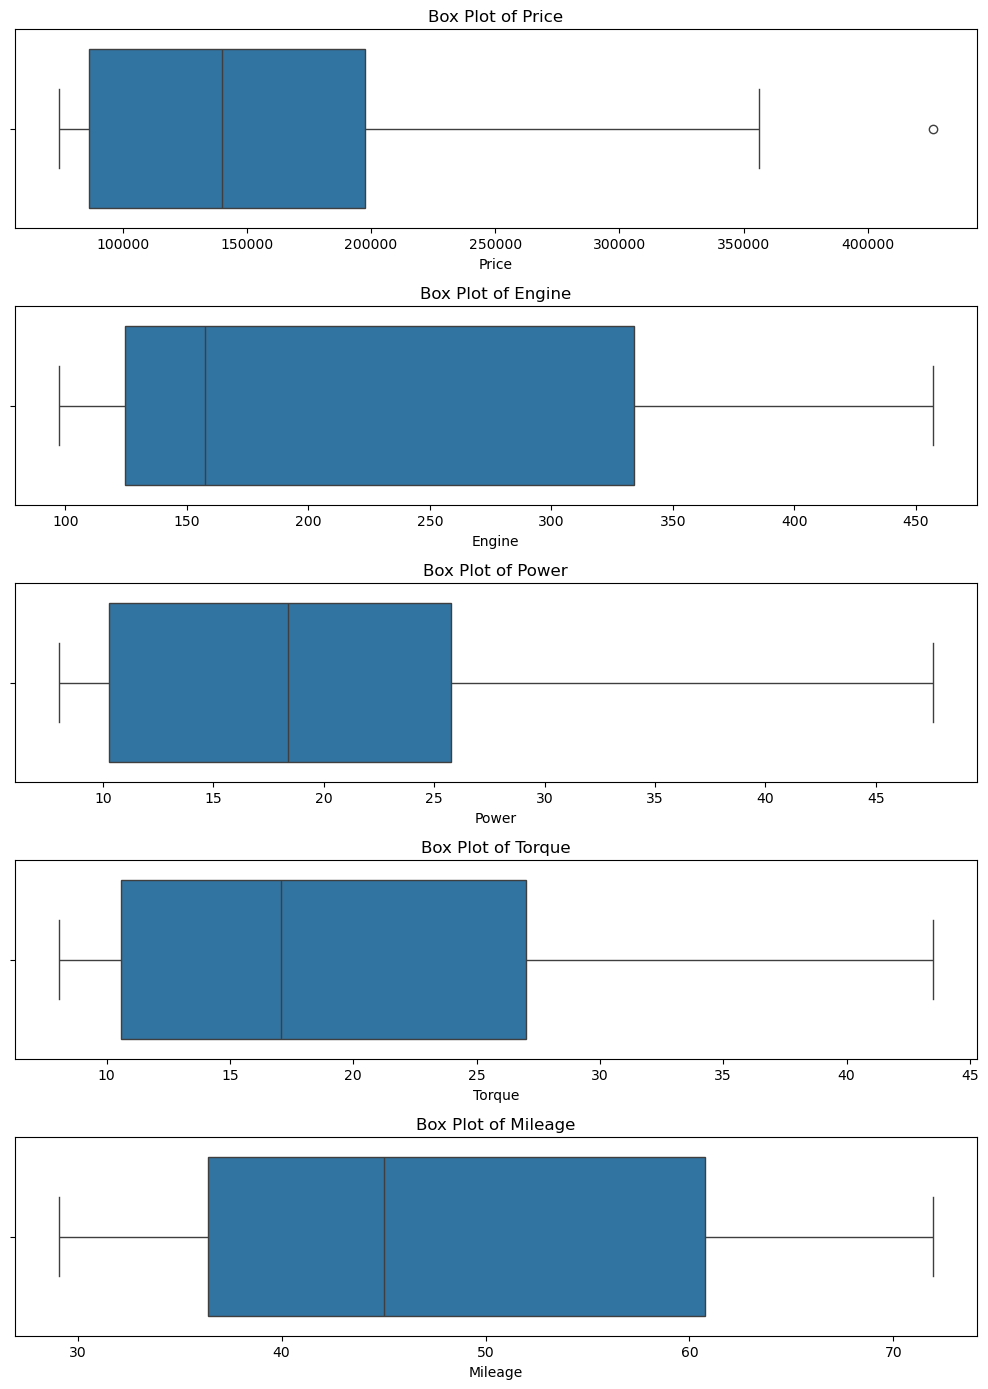

In [73]:
fig, axes = plt.subplots(5, 1, figsize=(10, 14))
for ax, col in zip(axes, ["Price", "Engine", "Power", "Torque", "Mileage"]):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Box Plot of {col}")
plt.tight_layout()
plt.show()

In [74]:
print(df.isnull().sum())
print("\nVehicle type counts:")
print(df["Vehicle_Type"].value_counts())

Name             0
Price            0
Engine           2
Power            2
Torque           0
Mileage          4
URL              0
Power_kW        24
Range_km        24
Vehicle_Type     0
dtype: int64

Vehicle type counts:
Vehicle_Type
Petrol      24
Electric     2
Name: count, dtype: int64


### Interpretation – Data Cleaning

The data-cleaning process removed duplicate records, standardized column/text formatting, converted numerical fields to numeric data types, checked for negative/invalid values, and inspected missing values.

The dataset contains both petrol and electric bikes. Therefore, missing **Engine, Power and Mileage** values for electric bikes are not treated as errors. Electric bikes are represented using **Power_kW** and **Range_km**. The applicable missing torque value for Chetak was corrected using the value found during the scraping review.

Box plots and the IQR method were used to identify potential outliers. Extreme values were not automatically deleted because they may represent genuine premium or high-performance bikes.

# 9. Exploratory Data Analysis (EDA)

### Problem Statement

To perform exploratory data analysis on BikeDekho bike data and identify relationships between **Price** and other available features such as **Engine, Power, Torque, Mileage, Power_kW, Range_km** and **Vehicle_Type**.

In [75]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical Variables:")
print(categorical_columns)
print("\nNumerical Variables:")
print(numerical_columns)

Categorical Variables:
['Name', 'URL', 'Vehicle_Type']

Numerical Variables:
['Price', 'Engine', 'Power', 'Torque', 'Mileage', 'Power_kW', 'Range_km']


## 9.1 Univariate Analysis – Continuous Variables

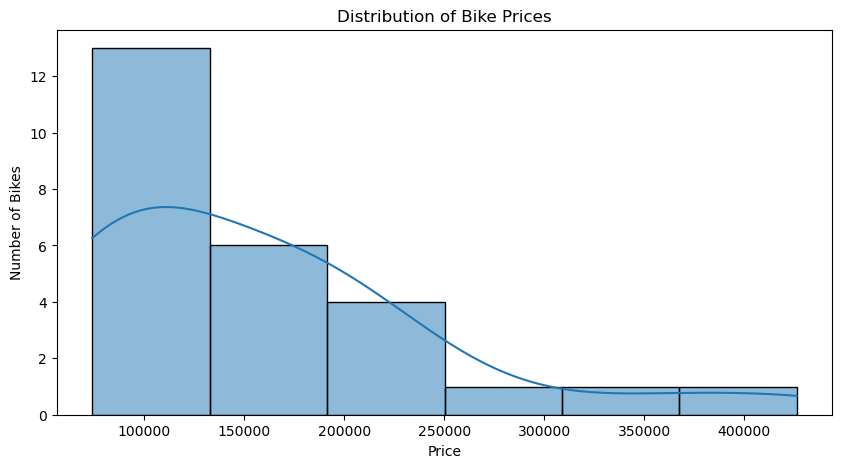

Mean: 157863.38461538462
Median: 140140.0
Mode: 74125.0
Standard Deviation: 88509.5527590449
Variance: 7833940929.606154
Minimum: 74125.0
Maximum: 426223.0


In [76]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Price"], kde=True)
plt.title("Distribution of Bike Prices")
plt.xlabel("Price")
plt.ylabel("Number of Bikes")
plt.show()

print("Mean:", df["Price"].mean())
print("Median:", df["Price"].median())
print("Mode:", df["Price"].mode()[0])
print("Standard Deviation:", df["Price"].std())
print("Variance:", df["Price"].var())
print("Minimum:", df["Price"].min())
print("Maximum:", df["Price"].max())

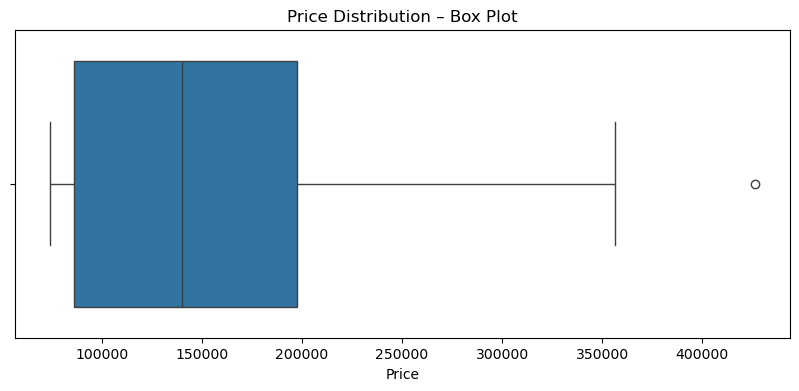

In [77]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Price"])
plt.title("Price Distribution – Box Plot")
plt.xlabel("Price")
plt.show()

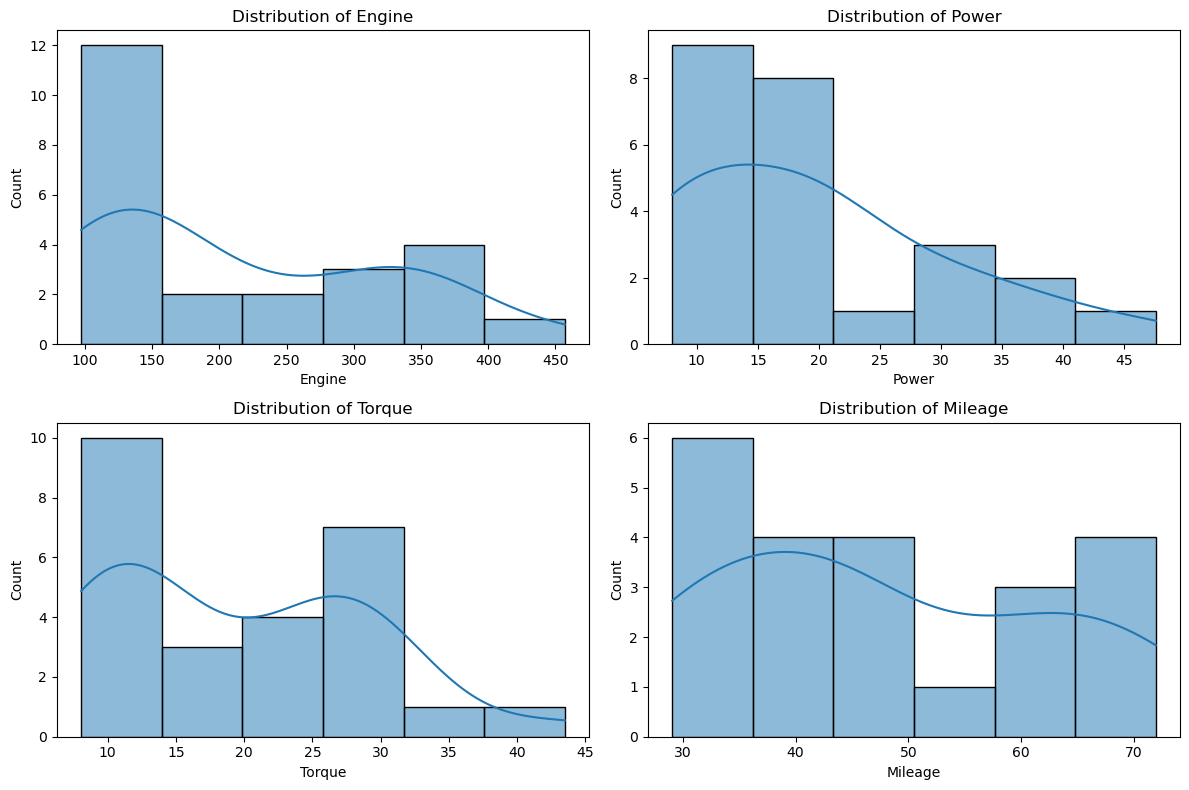

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["Engine", "Power", "Torque", "Mileage"]):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [79]:
dispersion = df[["Price", "Engine", "Power", "Torque", "Mileage", "Power_kW", "Range_km"]].describe().T
dispersion[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
Price,157863.384615,88509.552759,74125.00,86186.2500,140140.000,197572.7500,426223.00
Engine,215.263333,108.471548,97.20,124.5250,157.350,334.0000,457.00
Power,19.708750,11.100590,7.99,10.2575,18.400,25.7425,47.58
Torque,19.486923,9.632315,8.05,10.6000,17.065,27.0000,43.50
Mileage,47.655000,14.673057,29.06,36.4000,45.000,60.7750,71.94
Power_kW,6.000000,0.000000,6.00,6.0000,6.000,6.0000,6.00
Range_km,112.000000,26.870058,93.00,102.5000,112.000,121.5000,131.00


### Continuous-variable interpretation

- **Price:** The prices show clear variation because the sample contains commuter, premium and performance-oriented bikes.
- **Engine:** Engine capacity varies substantially; larger engines are generally associated with performance-oriented motorcycles.
- **Power and Torque:** Both measures vary across motorcycles, reflecting differences in performance.
- **Mileage:** Mileage varies across models, with commuter-oriented bikes generally designed for better fuel efficiency.
- **Electric variables:** Power_kW and Range_km apply only to the electric bikes in this sample, so their missing values for petrol bikes are expected.

## 9.2 Univariate Analysis – Categorical Variables

Frequency:
Vehicle_Type
Petrol      24
Electric     2
Name: count, dtype: int64

Percentage:
Vehicle_Type
Petrol      92.31
Electric     7.69
Name: proportion, dtype: float64


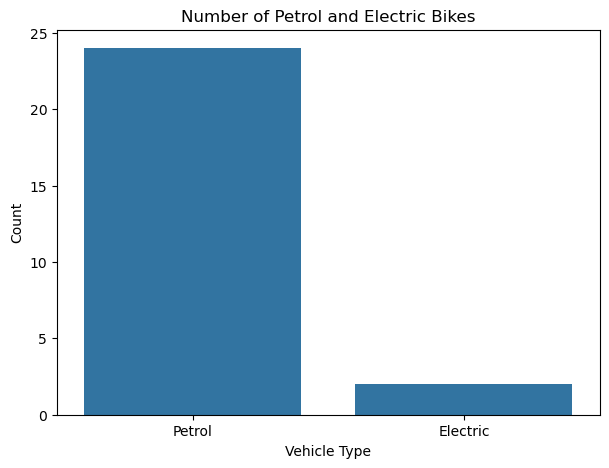

In [80]:
vehicle_counts = df["Vehicle_Type"].value_counts()
vehicle_percentage = df["Vehicle_Type"].value_counts(normalize=True).mul(100).round(2)

print("Frequency:")
print(vehicle_counts)
print("\nPercentage:")
print(vehicle_percentage)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Vehicle_Type")
plt.title("Number of Petrol and Electric Bikes")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")
plt.show()

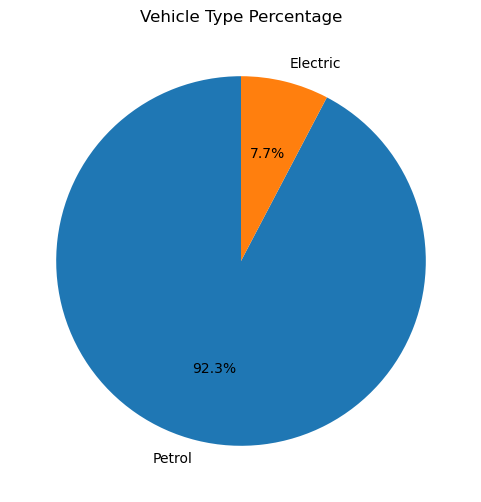

In [81]:
plt.figure(figsize=(6, 6))
vehicle_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Vehicle Type Percentage")
plt.ylabel("")
plt.show()

### Categorical-variable interpretation

The scraped sample contains substantially more petrol bikes than electric bikes. Therefore, conclusions about electric bikes should be treated cautiously because the electric group is much smaller.

## 9.3 Bivariate Analysis – Continuous + Continuous

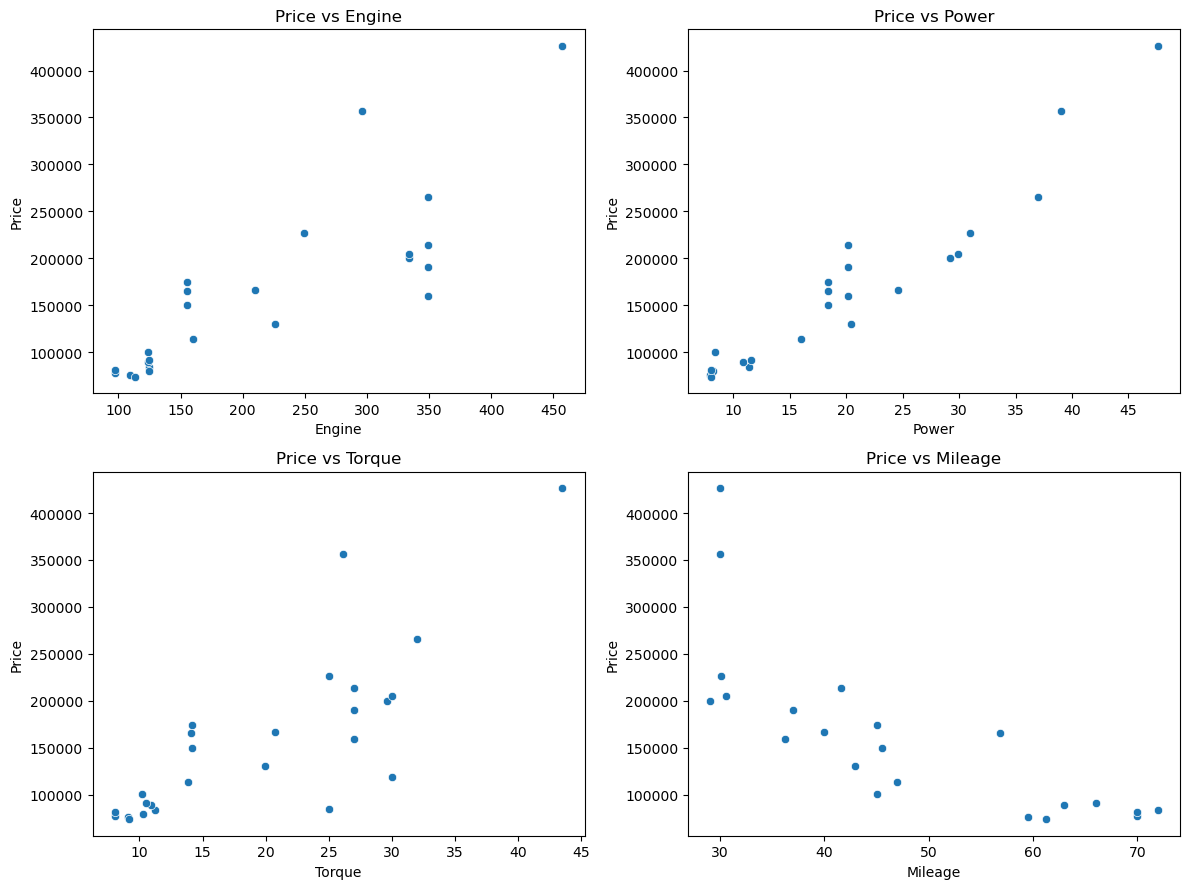

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.ravel(), ["Engine", "Power", "Torque", "Mileage"]):
    sns.scatterplot(data=df, x=col, y="Price", ax=ax)
    ax.set_title(f"Price vs {col}")
plt.tight_layout()
plt.show()

             Price    Engine     Power    Torque   Mileage  Power_kW  Range_km
Price     1.000000  0.833735  0.956530  0.797014 -0.759711       NaN       1.0
Engine    0.833735  1.000000  0.848839  0.983286 -0.826045       NaN       NaN
Power     0.956530  0.848839  1.000000  0.918455 -0.824574       NaN       NaN
Torque    0.797014  0.983286  0.918455  1.000000 -0.847393       NaN       1.0
Mileage  -0.759711 -0.826045 -0.824574 -0.847393  1.000000       NaN       NaN
Power_kW       NaN       NaN       NaN       NaN       NaN       NaN       NaN
Range_km  1.000000       NaN       NaN  1.000000       NaN       NaN       1.0


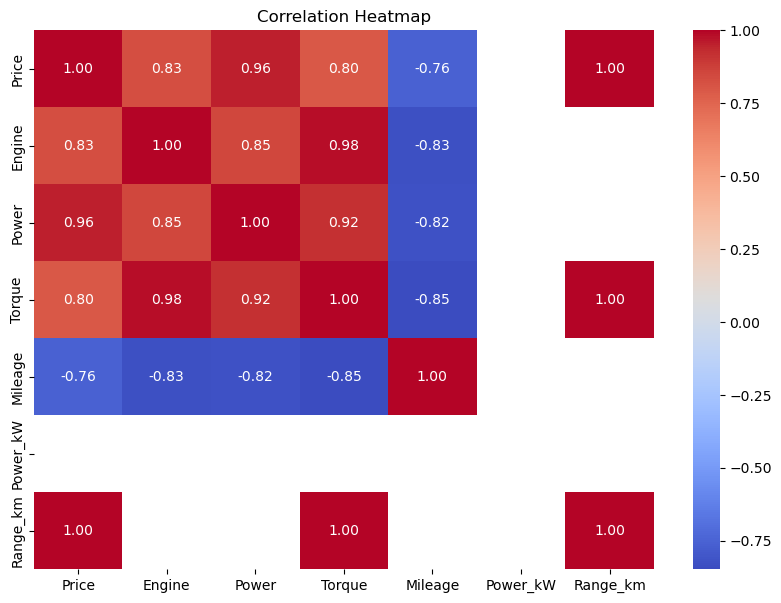

In [83]:
correlation = df[["Price", "Engine", "Power", "Torque", "Mileage", "Power_kW", "Range_km"]].corr()
print(correlation)

plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Continuous + continuous interpretation

The scatter plots and correlation matrix help identify how bike price moves with technical specifications. In this sample, price generally tends to increase with performance-related specifications such as engine capacity, power and torque. Mileage does not necessarily increase with price because premium/performance bikes can prioritize performance and features over fuel economy. Correlation values should be interpreted carefully because the sample is small and contains different vehicle categories.

## 9.4 Bivariate Analysis – Continuous + Categorical

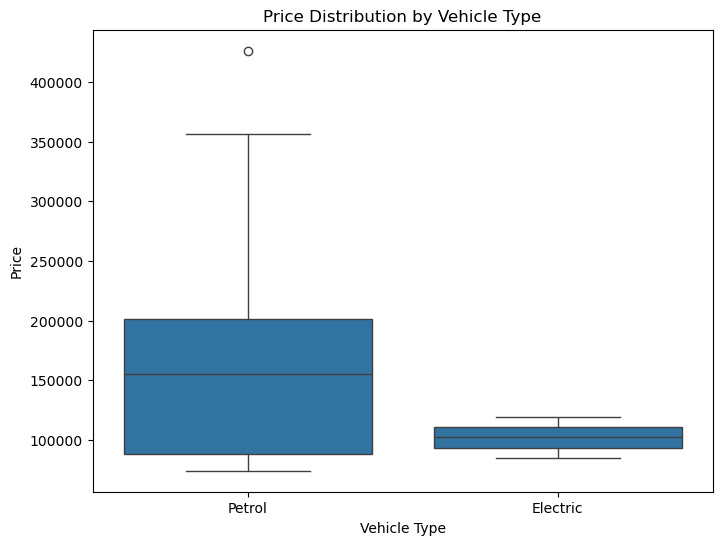

              count           mean    median      min       max
Vehicle_Type                                                   
Electric          2  102134.500000  102134.5  84999.0  119270.0
Petrol           24  162507.458333  154823.0  74125.0  426223.0


In [84]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Vehicle_Type", y="Price")
plt.title("Price Distribution by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Price")
plt.show()

print(df.groupby("Vehicle_Type")["Price"].agg(["count", "mean", "median", "min", "max"]))

In [85]:
petrol_engine_summary = df[df["Vehicle_Type"] == "Petrol"].groupby("Vehicle_Type")["Engine"].agg(["mean", "median", "min", "max"])
petrol_engine_summary

,mean,median,min,max
Vehicle_Type,,,,
Petrol,215.263333,157.35,97.2,457.0


In [86]:
price_pivot = pd.pivot_table(
    df,
    values="Price",
    index="Vehicle_Type",
    aggfunc=["mean", "median", "min", "max"]
)
price_pivot

,mean,median,min,max
,Price,Price,Price,Price
Vehicle_Type,,,,
Electric,102134.500000,102134.5,84999.0,119270.0
Petrol,162507.458333,154823.0,74125.0,426223.0


### Continuous + categorical interpretation

Grouping price by vehicle type shows whether petrol and electric bikes occupy different price ranges in this scraped sample. Because the electric group contains only a small number of observations, the group-level comparison should be viewed as descriptive rather than a general market conclusion.

## 9.5 Bivariate Analysis – Categorical + Categorical

In [87]:
df["Price_Category"] = pd.cut(
    df["Price"],
    bins=[0, 100000, 200000, 500000, np.inf],
    labels=["Budget", "Mid-Range", "Premium", "Luxury"]
)

price_vehicle_crosstab = pd.crosstab(df["Vehicle_Type"], df["Price_Category"])
print(price_vehicle_crosstab)

print("\nRow percentages:")
print((pd.crosstab(df["Vehicle_Type"], df["Price_Category"], normalize="index") * 100).round(2))

Price_Category  Budget  Mid-Range  Premium
Vehicle_Type                              
Electric             1          1        0
Petrol               8         10        6

Row percentages:
Price_Category  Budget  Mid-Range  Premium
Vehicle_Type                              
Electric         50.00      50.00      0.0
Petrol           33.33      41.67     25.0


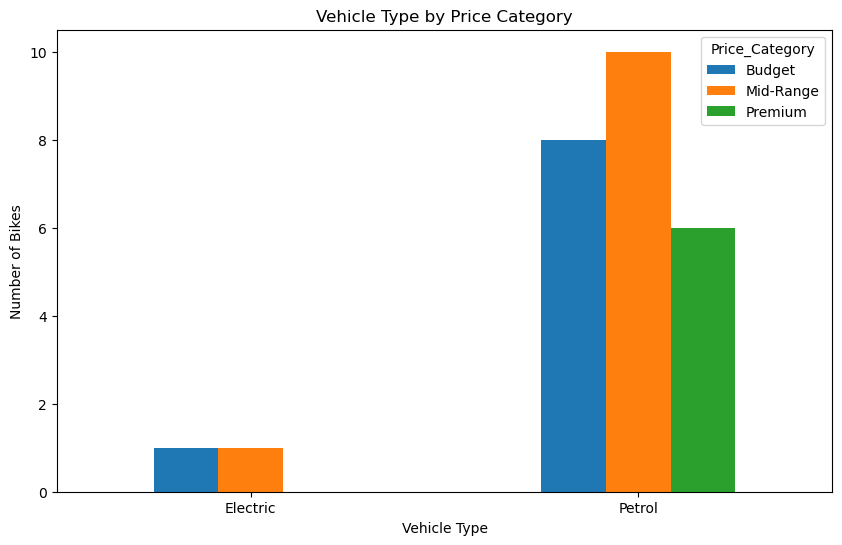

In [88]:
price_vehicle_crosstab.plot(kind="bar", figsize=(10, 6))
plt.title("Vehicle Type by Price Category")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Bikes")
plt.xticks(rotation=0)
plt.show()

### Categorical + categorical interpretation

The crosstab compares vehicle type with price category. It helps show how the petrol and electric observations are distributed across budget, mid-range, premium and luxury groups. Since the dataset is a small scraped sample, these proportions describe this dataset rather than the complete BikeDekho market.

## 9.6 Multivariate Analysis

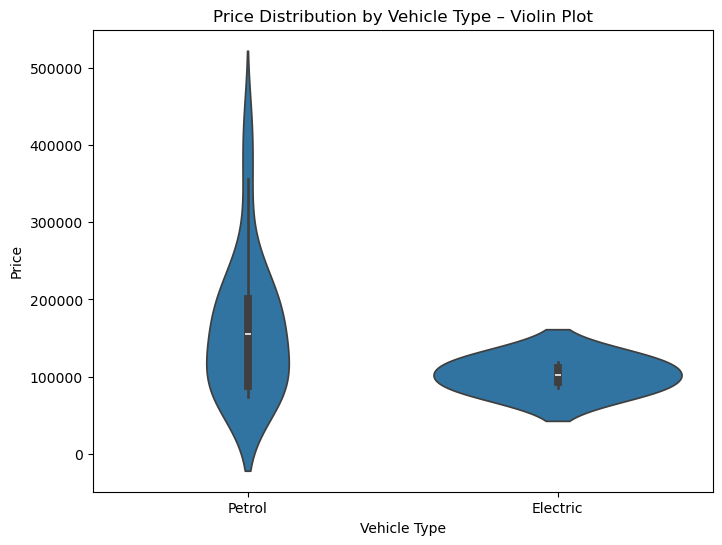

In [89]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x="Vehicle_Type", y="Price")
plt.title("Price Distribution by Vehicle Type – Violin Plot")
plt.xlabel("Vehicle Type")
plt.ylabel("Price")
plt.show()

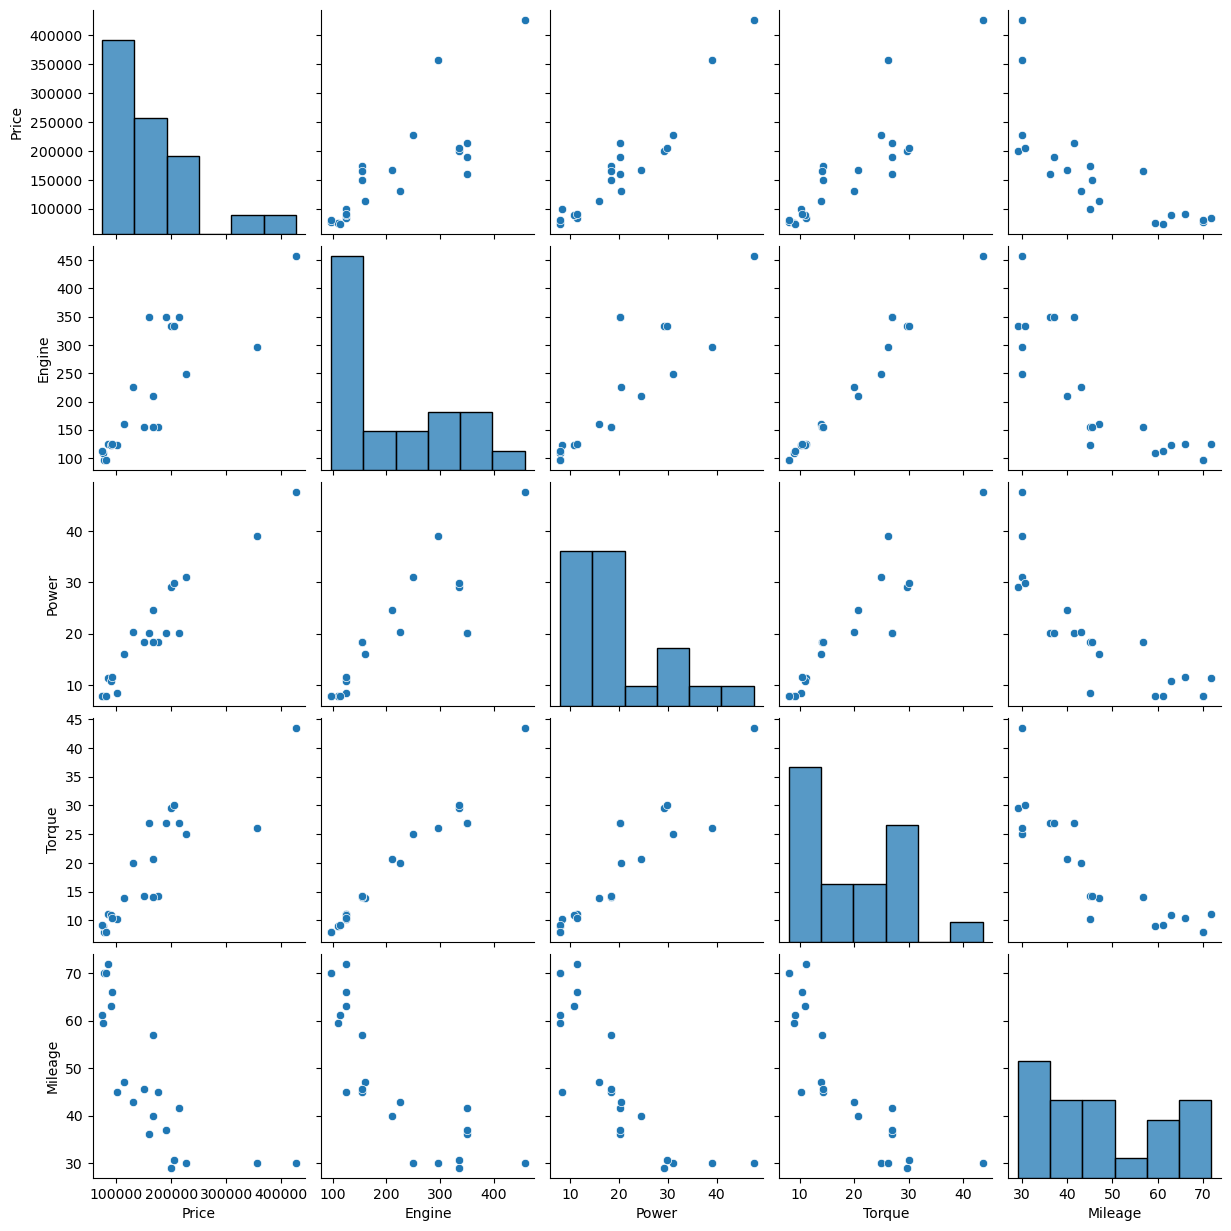

In [90]:
pair_data = df[["Price", "Engine", "Power", "Torque", "Mileage"]].dropna()
sns.pairplot(pair_data, diag_kind="hist")
plt.show()

,Name,Price,Engine,Power,Torque,Vehicle_Type
22,Aprilia RS 457,426223.0,457.00,47.58,43.50,Petrol
24,New Kawasaki Ninja 300,356381.0,296.00,39.00,26.10,Petrol
20,New Triumph Speed 400,265498.0,349.00,37.00,32.00,Petrol
23,New KTM 250 Duke,226767.0,249.07,31.00,25.00,Petrol
0,Royal Enfield Classic 350,214270.0,349.00,20.21,27.00,Petrol
25,Jawa 42 Bobber,204950.0,334.00,29.92,30.00,Petrol
19,New Yezdi Roadster,199969.0,334.00,29.17,29.63,Petrol
5,"Royal Enfield Bullet 350 - Icon Since 1932,",190384.0,349.00,20.21,27.00,Petrol
2,New Yamaha R15 V4,174850.0,155.00,18.40,14.20,Petrol
18,Hero XPulse 210,166745.0,210.00,24.60,20.70,Petrol


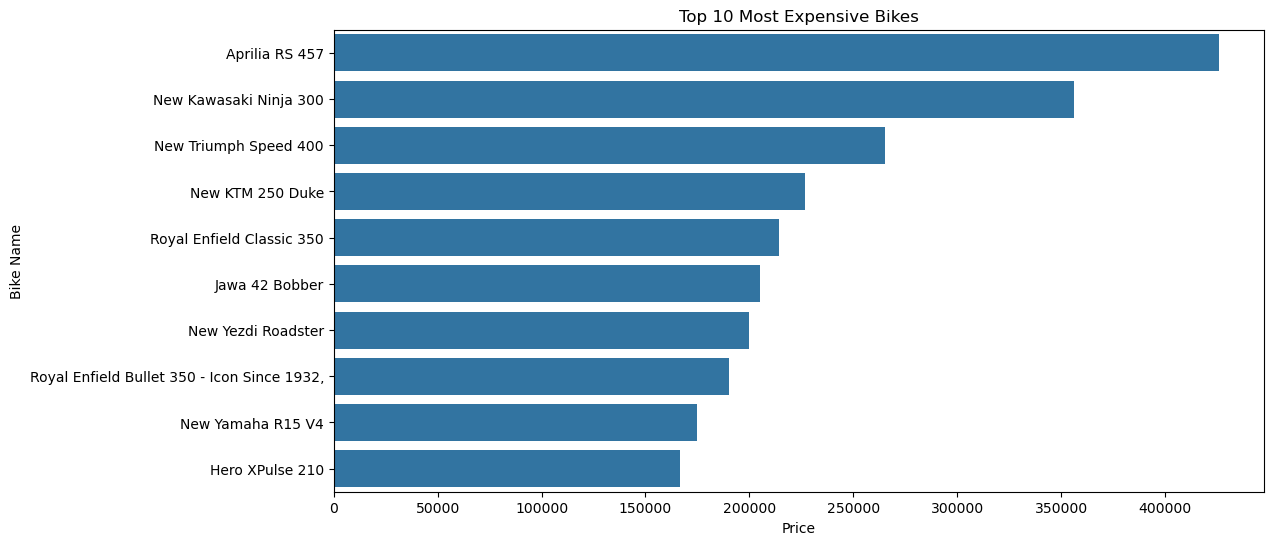

In [91]:
top_10_expensive = df.sort_values("Price", ascending=False).head(10)
display(top_10_expensive[["Name", "Price", "Engine", "Power", "Torque", "Vehicle_Type"]])

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_expensive, x="Price", y="Name")
plt.title("Top 10 Most Expensive Bikes")
plt.xlabel("Price")
plt.ylabel("Bike Name")
plt.show()

In [92]:
cheapest_10 = df.sort_values("Price", ascending=True).head(10)
display(cheapest_10[["Name", "Price", "Engine", "Power", "Mileage", "Vehicle_Type"]])

,Name,Price,Engine,Power,Mileage,Vehicle_Type
15,New TVS Jupiter,74125.0,113.30,8.02,61.20,Petrol
4,"Honda Activa - India's No.1 Selling Scooter,",76083.0,109.51,7.99,59.50,Petrol
1,"Hero Splendor Plus - India's No.1 Selling Bike,",77777.0,97.20,8.02,70.00,Petrol
12,New Yamaha RayZR 125 Fi Hybrid,79880.0,125.00,8.20,NaN,Petrol
17,Hero Splendor Plus XTEC,81283.0,97.20,8.02,70.00,Petrol
6,TVS Raider,83910.0,124.80,11.38,71.94,Petrol
16,Vida VX2,84999.0,NaN,NaN,NaN,Electric
13,New Honda SP 125:,89748.0,123.94,10.87,63.00,Petrol
21,"Xtreme 125R: Get Sep 2026 Offers, On-Road",91500.0,124.70,11.55,66.00,Petrol
8,"Suzuki Access 125 - Scooter Of The Year,",100400.0,124.00,8.42,45.00,Petrol


### Multivariate interpretation

The pair plot, violin plot and price rankings show that bike price is influenced by multiple specifications rather than one feature alone. Performance-related variables tend to move together for many petrol motorcycles, while mileage often represents a different design priority. The vehicle type comparison also shows that petrol and electric bikes should be analyzed with their applicable specifications rather than treating all columns as universally relevant.

## 10. Overall EDA Interpretations

1. **Price:** Bike prices vary considerably across commuter, premium and performance segments.
2. **Engine:** Larger engine capacities are generally associated with higher-performance and higher-priced motorcycles.
3. **Power:** Higher power is generally associated with premium or performance-oriented bikes and tends to accompany higher prices.
4. **Torque:** Torque shows a similar performance relationship and tends to increase with engine/power for many petrol motorcycles.
5. **Mileage:** Commuter-oriented motorcycles generally show better mileage, while premium/performance models may trade mileage for performance.
6. **Vehicle Type:** Petrol bikes dominate the scraped sample, so electric-bike conclusions are based on fewer observations.
7. **Outliers:** Some high prices or high-performance specifications are legitimate observations rather than data-entry errors.
8. **Overall relationship:** Price is influenced by several factors together, including engine capacity, power, torque, mileage, vehicle type, brand and product positioning.

## 11. Conclusion

The BikeDekho dataset was successfully exported to CSV, imported and cleaned before exploratory analysis. The dataset was checked for observations, features, data types, missing values, duplicates, invalid numerical values and potential outliers. Numerical columns were converted to appropriate data types and petrol/electric specifications were handled according to their applicability.

EDA was performed using univariate, bivariate and multivariate techniques, including histograms, KDE, box plots, count plots, pie charts, scatter plots, bar charts, violin plots, pair plots, pivot tables, crosstabs and a correlation heatmap.

The analysis indicates that higher engine capacity, power and torque are generally associated with higher bike prices in this scraped sample, while commuter-oriented bikes tend to provide better mileage. Price is not determined by a single specification; brand, vehicle type, performance and product positioning also contribute.

**Final conclusion:** The BikeDekho sample demonstrates clear variation across bike segments, and exploratory analysis provides useful insights into how technical specifications and vehicle type are related to bike pricing. These findings are descriptive of the scraped sample and should not be treated as a complete representation of the entire market.